# Titanic Dataset Brief-Visulization Analysis

In [1]:
# Importing Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Dataset ( train.xlxs is the titanic dataset)

df = pd.read_excel('train.xlsx')

# Exploreing the Dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
rows,cols=df.shape
print(f"Rows:{rows}, columns:{cols}")

Rows:891, columns:12


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891.0,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681.0,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082.0,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7.0,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
# Data Pre-processing

df.drop('Cabin',axis=1,inplace=True) # dropped cabin

In [9]:
df.fillna({'Age': df['Age'].mean()}, inplace=True) # filling missing age by mean

In [11]:
df.dropna(subset=['Embarked'],inplace=True)  # droppping row with missing embarked row

In [13]:
# Univariate Visulization 

<Axes: xlabel='Survived', ylabel='count'>

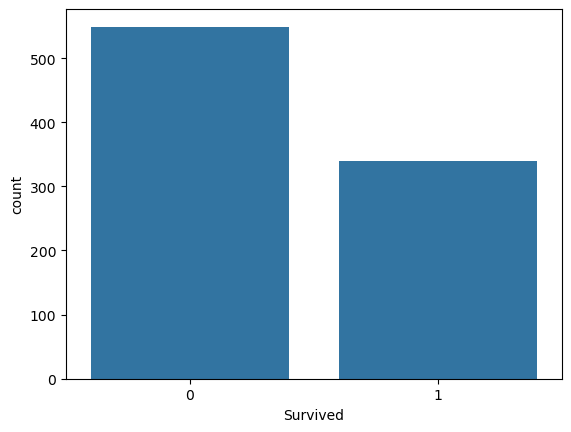

In [15]:
sns.countplot(x='Survived',data=df) # bar plot of survived vs non - survived

(array([ 40.,  14.,  15.,  31.,  79.,  98.,  85., 261.,  73.,  44.,  35.,
         35.,  29.,  16.,  13.,  10.,   4.,   5.,   1.,   1.]),
 array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
        32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
        64.084, 68.063, 72.042, 76.021, 80.   ]),
 <BarContainer object of 20 artists>)

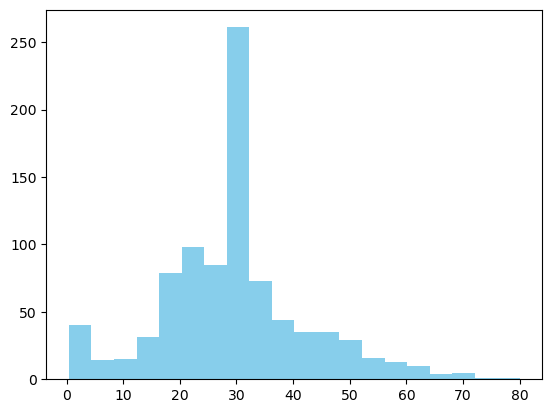

In [17]:
plt.hist(df['Age'],bins=20,color='skyblue') # histogram for age distibution

<Axes: ylabel='count'>

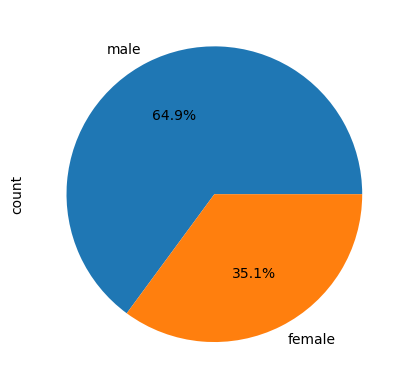

In [19]:
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%') # pie chart for Gender distibution 

In [21]:
# bivariate Visulization

<Axes: xlabel='Pclass', ylabel='Survived'>

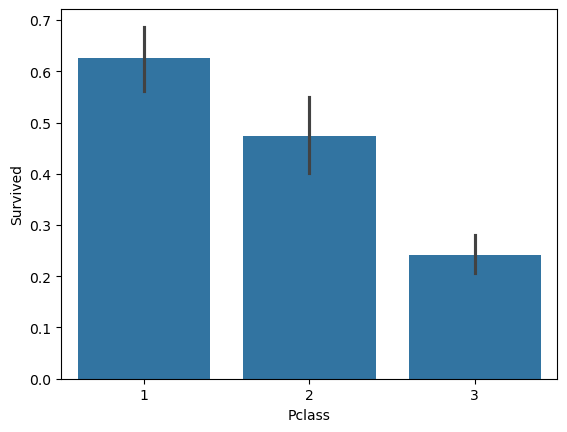

In [23]:
sns.barplot(x='Pclass',y='Survived',data=df) # bar plot for survival rate by class

<Axes: xlabel='Age', ylabel='Fare'>

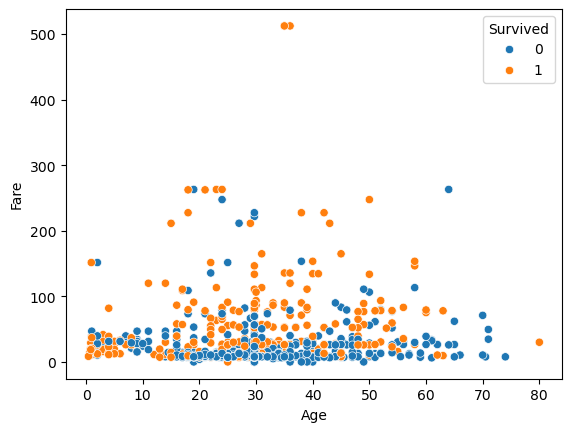

In [25]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df) # scatter plot for age vs fare

<Axes: xlabel='Pclass', ylabel='Fare'>

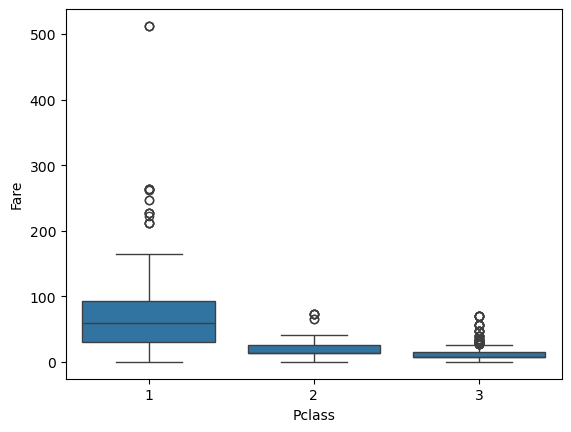

In [27]:
sns.boxplot(x='Pclass',y='Fare',data=df) # box plot for fare by class

In [29]:
# multivariate visulization 

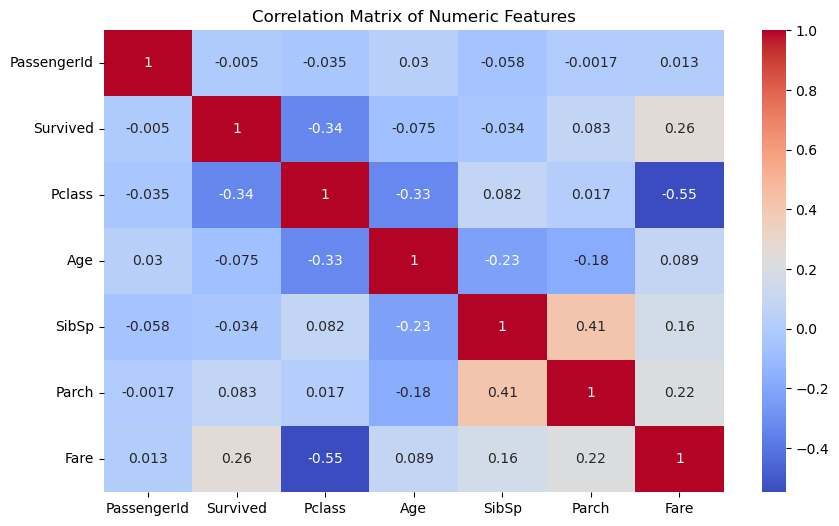

In [31]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

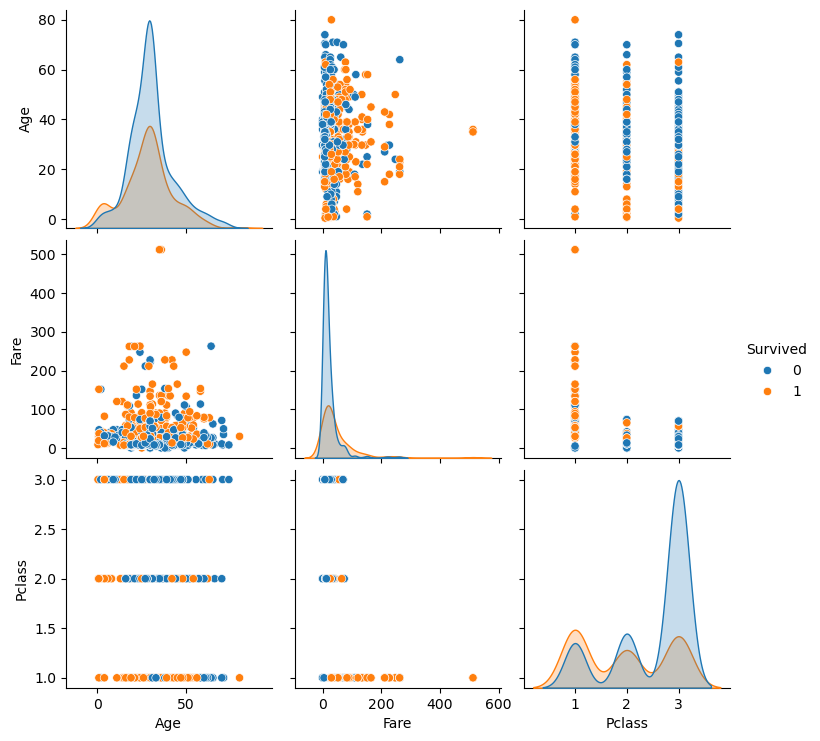

In [33]:
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived') # pair plot multivariable

In [35]:
# 3D plot and maps

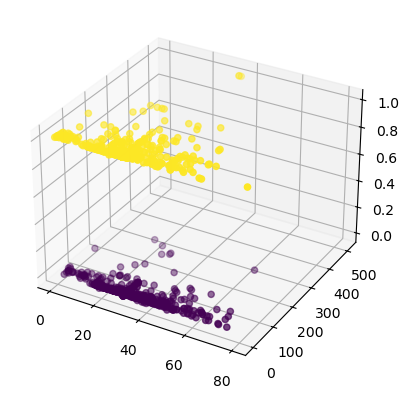

In [37]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['Fare'], df['Survived'], c=df['Survived'])

<Axes: xlabel='Longitude', ylabel='Latitude'>

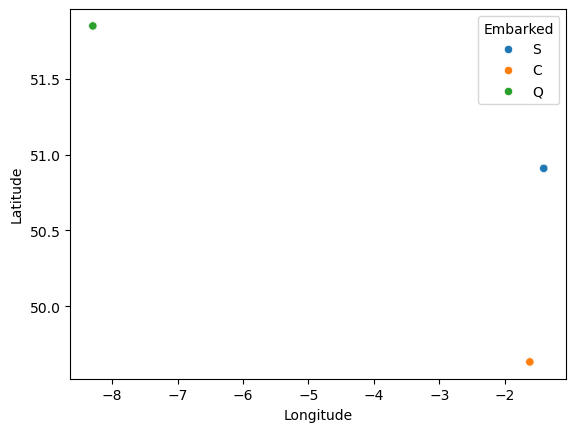

In [39]:
embark_coords = {'S': [50.9097, -1.4044], 'C': [49.6333, -1.6167], 'Q': [51.8490, -8.2940]}
df['Latitude'] = df['Embarked'].map(lambda x: embark_coords[x][0])
df['Longitude'] = df['Embarked'].map(lambda x: embark_coords[x][1])
sns.scatterplot(x='Longitude', y='Latitude', hue='Embarked', data=df)

<BarContainer object of 3 artists>

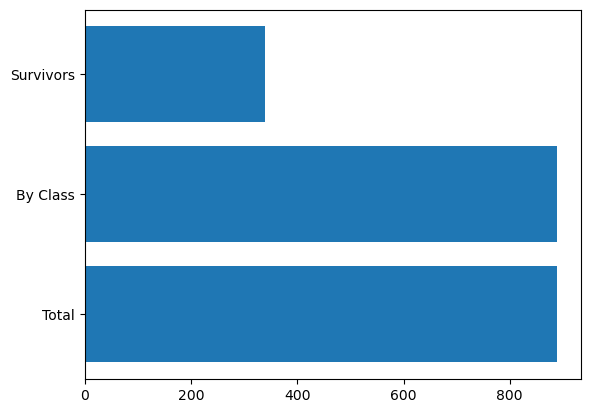

In [41]:
stages = {
    'Total': len(df),
    'By Class': df['Pclass'].value_counts().sum(),
    'Survivors': df['Survived'].sum()
}
plt.barh(list(stages.keys()), list(stages.values()))

<Axes: xlabel='Age', ylabel='Count'>

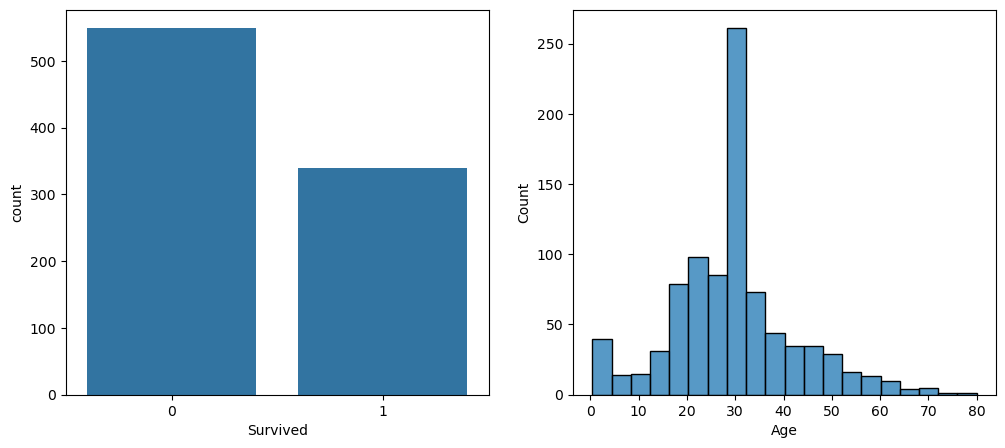

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Survived', data=df, ax=axs[0])
sns.histplot(df['Age'], bins=20, ax=axs[1])

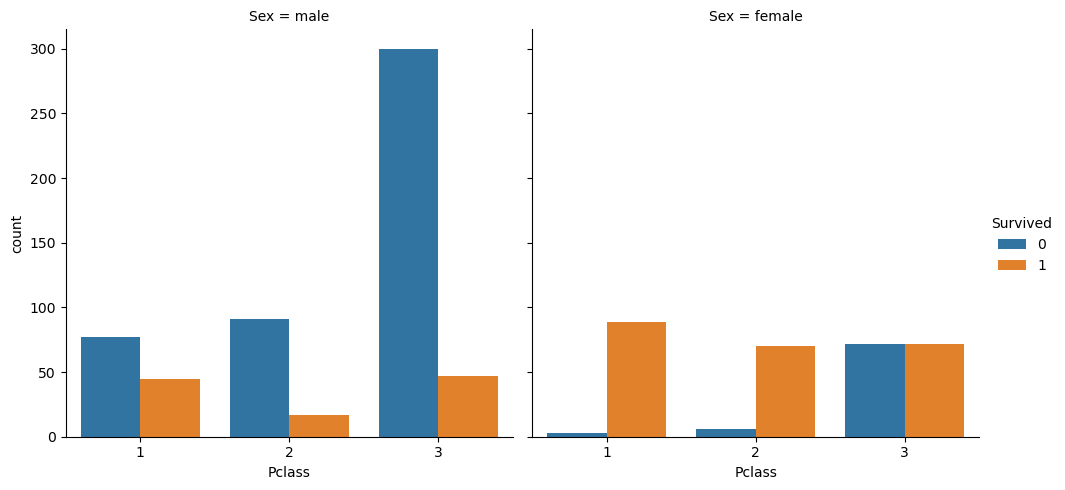

In [45]:
sns.catplot(x='Pclass', hue='Survived', col='Sex', kind='count', data=df)

## Conclusion :


- **Survival Distribution:** More passengers did not survive than survived. The count plot shows a clear difference, indicating survival was less likely overall.
- **Age Distribution:** The majority of passengers were young adults, but all age groups, including children and elders, are represented.
- **Class and Survival:** Visualizations reveal that **survival rates were higher in 1st class than in 2nd or 3rd class**.
- **Gender Differences:** Females, especially in 1st class, had higher survival rates compared to males across all classes.
